In [17]:
from langgraph.graph import StateGraph,START,END 
from typing import TypedDict 
import time 


In [18]:
class Crash_state(TypedDict): 
    input: str 
    step_1: str 
    step_2: str 
    step_3: str 
    
    
    

In [19]:
#lets make a graph 
graph=StateGraph(Crash_state) 

In [20]:
def Step_1(state: Crash_state)-> Crash_state: 
    print('step 1 is done ')
    return {'step_1':'done'} 



def Step_2(state: Crash_state)-> Crash_state: 
    print('Step 2 is running you can interrupt it') 
    time.sleep(30)
    return {'step_2': 'done'} 


def Step_3(state: Crash_state)-> Crash_state: 
    print('Step 3 is running ') 
    return {'step_3':'done'} 

In [21]:
#now lets add teh nodes and the edges in the graph 

#nodes
graph.add_node('STEP_1',Step_1) 
graph.add_node('STEP_2',Step_2) 
graph.add_node('STEP_3',Step_3) 


#edges 
graph.add_edge(START,'STEP_1') 
graph.add_edge('STEP_1','STEP_2')
graph.add_edge('STEP_2','STEP_3') 
graph.add_edge('STEP_3',END)    

In [22]:
from langgraph.checkpoint.memory import InMemorySaver 
checkpoint=InMemorySaver() 
workflow=graph.compile(checkpointer=checkpoint)

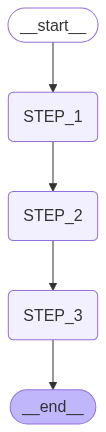

In [23]:
workflow 

In [24]:
#now lets invoke it 
initial_state={'input':'hello'} 
config={'configurable':{'thread_id':'1'}} 
try: 
    print('workflow is running please interrupt while step 2') 
    
    workflow.invoke(initial_state,config=config) 
except KeyboardInterrupt: 
    print('your workflow is interrupted') 
    

workflow is running please interrupt while step 2
step 1 is done 
Step 2 is running you can interrupt it
your workflow is interrupted


In [25]:
#lets extract the values of the state 
workflow.get_state(config)

StateSnapshot(values={'input': 'hello', 'step_1': 'done'}, next=('STEP_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c91-7f0b-69b2-8001-18bda25e9374'}}, metadata={'source': 'loop', 'writes': {'STEP_1': {'step_1': 'done'}}, 'step': 1, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-15T11:15:04.552491+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c91-7f0b-69b1-8000-d354cc970663'}}, tasks=(PregelTask(id='4ed963a2-ead0-b207-70eb-a6baf4b9c074', name='STEP_2', path=('__pregel_pull', 'STEP_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [26]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'input': 'hello', 'step_1': 'done'}, next=('STEP_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c91-7f0b-69b2-8001-18bda25e9374'}}, metadata={'source': 'loop', 'writes': {'STEP_1': {'step_1': 'done'}}, 'step': 1, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-15T11:15:04.552491+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c91-7f0b-69b1-8000-d354cc970663'}}, tasks=(PregelTask(id='4ed963a2-ead0-b207-70eb-a6baf4b9c074', name='STEP_2', path=('__pregel_pull', 'STEP_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'hello'}, next=('STEP_1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c91-7f0b-69b1-8000-d354cc970663'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-15T11:15:04.552491+00:00', parent_

In [27]:
# now lets reume the execution of the workflow 
workflow.invoke(None,config=config) 
#as you can see directly step 2 is running by skipping the step 1 

Step 2 is running you can interrupt it
Step 3 is running 


{'input': 'hello', 'step_1': 'done', 'step_2': 'done', 'step_3': 'done'}

In [28]:
#lets extract the values of the state 
workflow.get_state(config)

StateSnapshot(values={'input': 'hello', 'step_1': 'done', 'step_2': 'done', 'step_3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c97-db5c-667c-8003-4d55771aaefa'}}, metadata={'source': 'loop', 'writes': {'STEP_3': {'step_3': 'done'}}, 'step': 3, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-15T11:17:55.293759+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c97-db5c-667b-8002-e582881e372c'}}, tasks=(), interrupts=())

In [ ]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'input': 'hello', 'step_1': 'done', 'step_2': 'done', 'step_3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c97-db5c-667c-8003-4d55771aaefa'}}, metadata={'source': 'loop', 'writes': {'STEP_3': {'step_3': 'done'}}, 'step': 3, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-15T11:17:55.293759+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c97-db5c-667b-8002-e582881e372c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'hello', 'step_1': 'done', 'step_2': 'done'}, next=('STEP_3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f079c97-db5c-667b-8002-e582881e372c'}}, metadata={'source': 'loop', 'writes': {'STEP_2': {'step_2': 'done'}}, 'step': 2, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-15T11:17:55.293759+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'c

: 